In [2]:
import os
from pathlib import Path

# import matplotlib.pyplot as plt
# import numpy as np
# import seaborn as sns
import tensorflow as tf

# from keras import layers
# from keras import models
# from IPython import display

In [4]:
# Set the seed value for experiment reproducibility.
SEED = 42
# tf.random.set_seed(seed)
# np.random.seed(seed)

In [8]:
# script_dir = Path(__file__).resolve().parent
data_dir = Path.cwd() / Path("datasets/mini_speech_commands/")

if not data_dir.exists():
    raise FileNotFoundError(f"Expected dataset folder at {data_dir}.")

classes = os.listdir(data_dir)
classes.remove("README.md")
trained_commands = ["go", "stop", "no", "yes"]
classes = [c for c in classes if c in trained_commands]
classes

['go', 'no', 'stop', 'yes']

In [14]:
BATCH_SIZE = 64

train, val = tf.keras.utils.audio_dataset_from_directory(
    directory=data_dir,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    seed=SEED,
    output_sequence_length=16000,
    subset='both'
    )

print(train)

Found 4000 files belonging to 4 classes.
Using 3200 files for training.
Using 800 files for validation.
<_BatchDataset element_spec=(TensorSpec(shape=(None, 16000, None), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [15]:
train.element_spec

(TensorSpec(shape=(None, 16000, None), dtype=tf.float32, name=None),
 TensorSpec(shape=(None,), dtype=tf.int32, name=None))

In [19]:
def squeeze(audio, labels):
    # audio_dataset_from_directory() returns a tf.datasets.Dataset yielding the tuple, (audio, labels)
    # -> audio = (batch_size, sequence_length, num_channels)
    # -> lables = (batch_size,)

    # This dataset only contains one channel of audio, so we will drop the num_channels axis
    audio = tf.squeeze(audio, axis=-1)
    return audio, labels

In [20]:
# Use tf.data.AUTOTUNE to automatically balance CPU cores to transform dataset elements in parallel
train = train.map(squeeze, tf.data.AUTOTUNE)
val = val.map(squeeze, tf.data.AUTOTUNE)

In [21]:
for example_audio, example_labels in train.take(1):
  print(example_audio.shape)
  print(example_labels.shape)

(64, 16000)
(64,)


In [30]:
import matplotlib.pyplot as plt
import numpy as np
from IPython import display

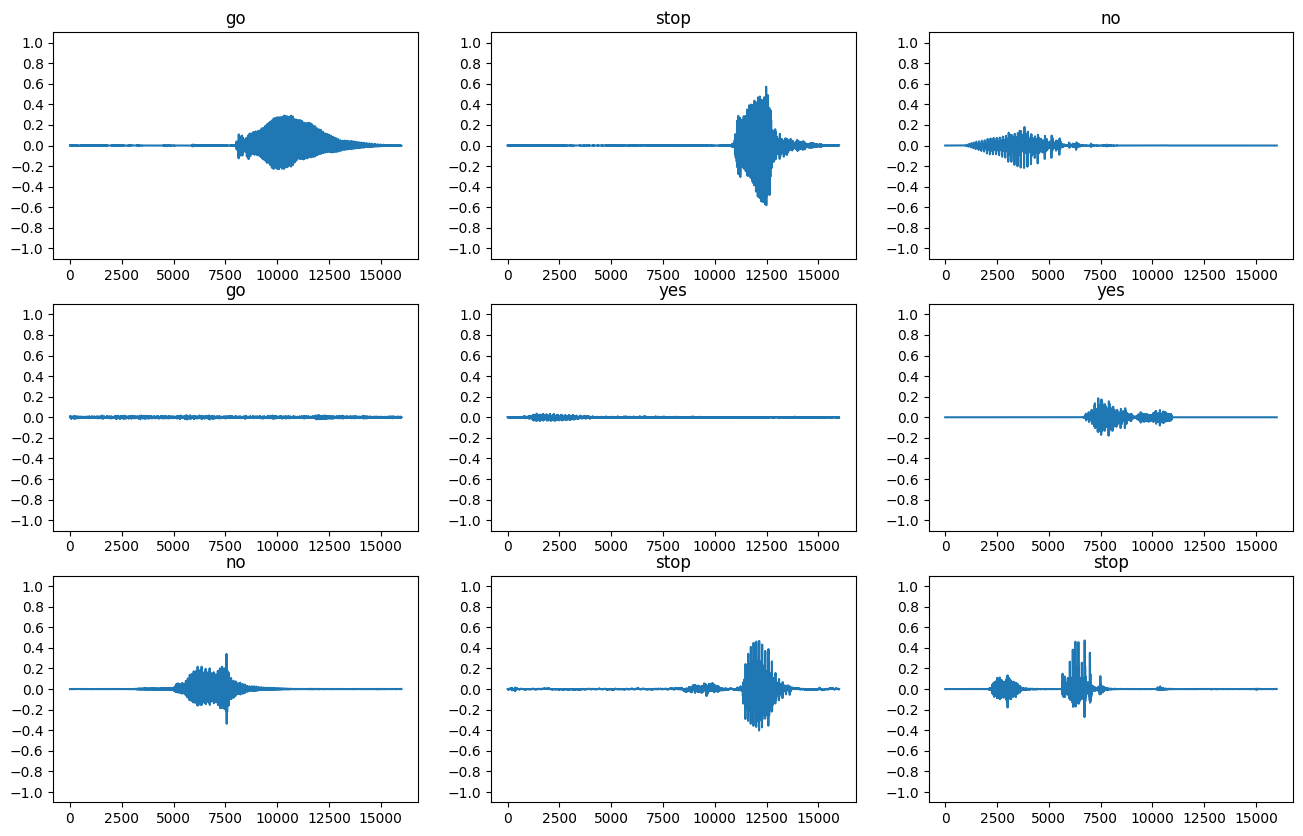

In [47]:
plt.figure(figsize=(16, 10))
rows = 3
cols = 3
n = rows * cols
for i in range(n):
  plt.subplot(rows, cols, i+1)
  audio_signal = example_audio[i]
  # print(audio_signal)
  # print(min(audio_signal.numpy()), max(audio_signal.numpy()))
  plt.plot(audio_signal)
  plt.title(classes[example_labels[i]])
  plt.yticks(np.arange(-1.2, 1.2, 0.2))
  plt.ylim([-1.1, 1.1])

# Convert Audio to Spectrograms

In [31]:
def get_spectrogram(waveform):
  # Convert the waveform to a spectrogram via a STFT.
  spectrogram = tf.signal.stft(
      waveform, frame_length=255, frame_step=128)
  # Obtain the magnitude of the STFT.
  spectrogram = tf.abs(spectrogram)
  # Add a `channels` dimension, so that the spectrogram can be used
  # as image-like input data with convolution layers (which expect
  # shape (`batch_size`, `height`, `width`, `channels`).
  spectrogram = spectrogram[..., tf.newaxis]
  return spectrogram

In [32]:
for i in range(3):
  label = classes[example_labels[i]]
  waveform = example_audio[i]
  spectrogram = get_spectrogram(waveform)
  print('Label:', label)
  print('Waveform shape:', waveform.shape)
  print('Spectrogram shape:', spectrogram.shape)
  print('Audio playback')
  display.display(display.Audio(waveform, rate=16000))

Label: go
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: stop
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


Label: no
Waveform shape: (16000,)
Spectrogram shape: (124, 129, 1)
Audio playback


In [33]:
def plot_spectrogram(spectrogram, ax):
  if len(spectrogram.shape) > 2:
    assert len(spectrogram.shape) == 3
    spectrogram = np.squeeze(spectrogram, axis=-1)
  # Convert the frequencies to log scale and transpose, so that the time is
  # represented on the x-axis (columns).
  # Add an epsilon to avoid taking a log of zero.
  log_spec = np.log(spectrogram.T + np.finfo(float).eps)
  height = log_spec.shape[0]
  width = log_spec.shape[1]
  X = np.linspace(0, np.size(spectrogram), num=width, dtype=int)
  Y = range(height)
  ax.pcolormesh(X, Y, log_spec)

(16000,)


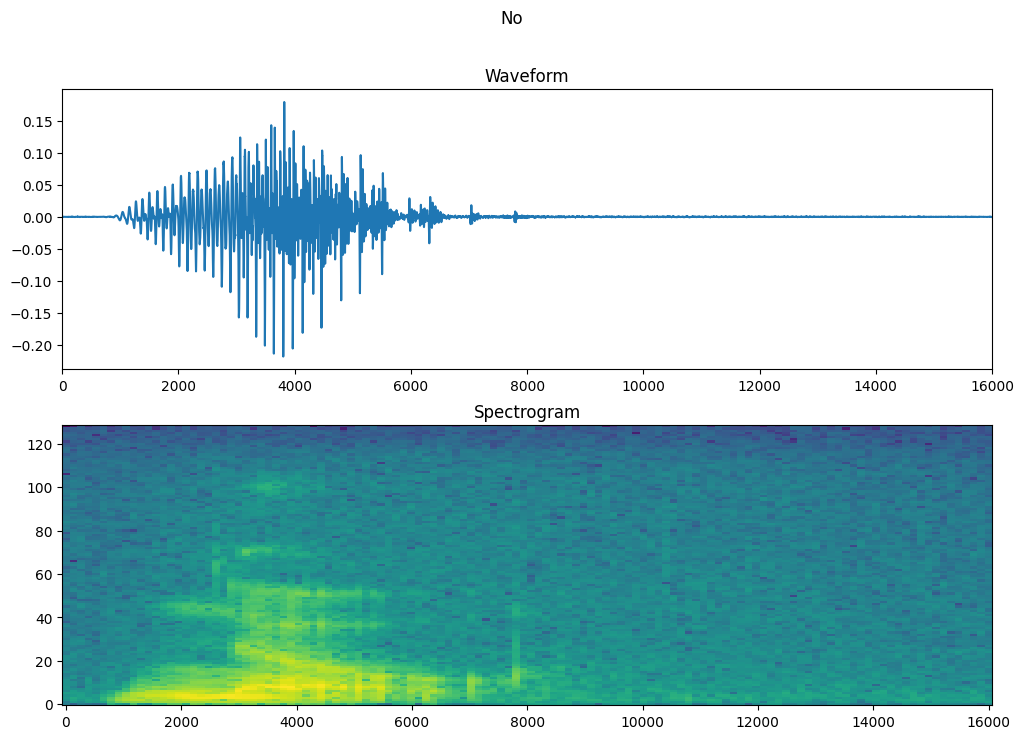

In [ ]:
fig, axes = plt.subplots(2, figsize=(12, 8))
timescale = np.arange(waveform.shape[0])
axes[0].plot(timescale, waveform.numpy())
axes[0].set_title('Waveform')
axes[0].set_xlim([0, 16000])

plot_spectrogram(spectrogram.numpy(), axes[1])
axes[1].set_title('Spectrogram')
plt.suptitle(label.title())
plt.show()

In [ ]:
input_shape = example_spectrograms.shape[1:]
print('Input shape:', input_shape)
num_labels = len(label_names)

# Instantiate the `tf.keras.layers.Normalization` layer.
norm_layer = layers.Normalization()
# Fit the state of the layer to the spectrograms
# with `Normalization.adapt`.
norm_layer.adapt(data=train_spectrogram_ds.map(map_func=lambda spec, label: spec))

model = models.Sequential([
    layers.Input(shape=input_shape),
    # Downsample the input.
    layers.Resizing(32, 32),
    # Normalize.
    norm_layer,
    layers.Conv2D(32, 3, activation='relu'),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_labels),
])

model.summary()
# Input shape: (124, 129, 1)
# [Model summary]